In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.shape

(45000, 14)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [8]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


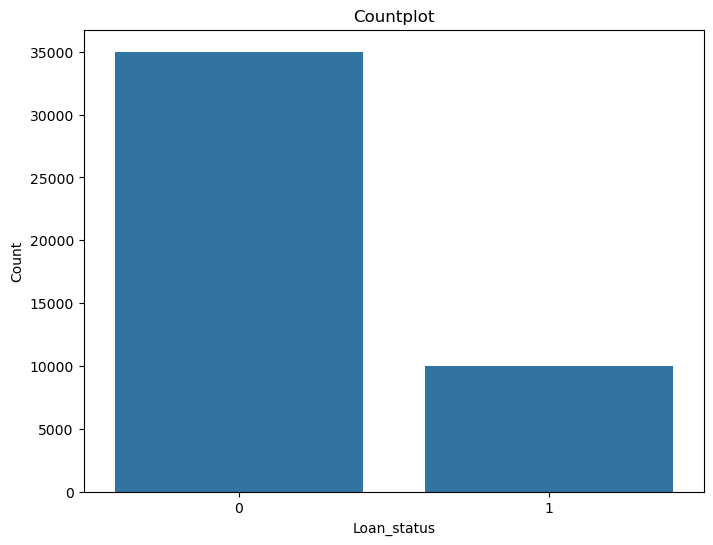

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(x='loan_status', data=df)
plt.title("Countplot")
plt.xlabel("Loan_status")
plt.ylabel("Count")
plt.show()

In [10]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [11]:
label_encoded = ['person_gender','previous_loan_defaults_on_file']
one_hot = ['person_education','person_home_ownership','loan_intent']

print("Label Encoded : ", label_encoded)
print("One_hot Encoded : ", one_hot)

Label Encoded :  ['person_gender', 'previous_loan_defaults_on_file']
One_hot Encoded :  ['person_education', 'person_home_ownership', 'loan_intent']


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in label_encoded:
    df[col] = le.fit_transform(df[col])

In [13]:
df = pd.get_dummies(df, columns=one_hot, drop_first=True)

In [14]:
df = df.astype(int)
df.head()

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,0,71948,0,35000,16,0,3,561,0,...,0,1,0,0,1,0,0,0,1,0
1,21,0,12282,0,1000,11,0,2,504,1,...,1,0,0,1,0,1,0,0,0,0
2,25,0,12438,3,5500,12,0,3,635,0,...,1,0,0,0,0,0,0,1,0,0
3,23,0,79753,0,35000,15,0,2,675,0,...,0,0,0,0,1,0,0,1,0,0
4,24,1,66135,1,35000,14,0,4,586,0,...,0,1,0,0,1,0,0,1,0,0


In [15]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("accuracy_score : ", accuracy_score(y_test, y_pred))
print("classification_report : ", classification_report(y_test, y_pred))
print("confusion_matrix : \n", confusion_matrix(y_test, y_pred))

accuracy_score :  0.8036666666666666
classification_report :                precision    recall  f1-score   support

           0       0.82      0.96      0.88      6990
           1       0.65      0.27      0.38      2010

    accuracy                           0.80      9000
   macro avg       0.73      0.61      0.63      9000
weighted avg       0.78      0.80      0.77      9000

confusion_matrix : 
 [[6697  293]
 [1474  536]]


In [20]:
print(df.select_dtypes(include="number").columns.tolist())

['person_age', 'person_gender', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [21]:
numerical_cols_for_outlier_removal = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'cb_person_cred_hist_length',
    'credit_score'
]

for col in numerical_cols_for_outlier_removal:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bond = Q1 - 1.5 * IQR
    upper_bond = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bond) & (df[col] <= upper_bond)]

In [22]:
X = df.drop('loan_status',axis = 1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [23]:
new_model = GaussianNB()
new_model.fit(X_train, y_train)
y_pred = new_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8515929560424789
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      5851
           1       0.78      0.42      0.55      1588

    accuracy                           0.85      7439
   macro avg       0.82      0.70      0.73      7439
weighted avg       0.84      0.85      0.83      7439

[[5662  189]
 [ 915  673]]


In [26]:
#Save the Model
import pickle
with open("naive_bayes_model.pkl","wb") as file:
    pickle.dump(new_model, file)

print("Saved")

Saved
